In [1]:
import sys
import torch
import torchvision
import torchaudio
import librosa
import numpy as np
import pandas as pd
import matplotlib
import sklearn

In [2]:
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Torchaudio:", torchaudio.__version__)
print("Librosa:", librosa.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA runtime:", torch.version.cuda)

Python: 3.11.16
PyTorch: 2.11.0+cu130
Torchvision: 0.26.0+cu130
Torchaudio: 2.11.0+cu130
Librosa: 0.11.0
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
CUDA runtime: 13.0


In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

folders = [
    "data/raw",
    "data/metadata",
    "data/processed",
    "notebooks",
    "src",
    "models",
    "results/figures",
    "results/metrics",
    "app"
]

for folder in folders:
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("\nCreated folders:")

for folder in folders:
    path = PROJECT_ROOT / folder
    print(f"{folder:<20} exists = {path.exists()}")

Project root: D:\Robotique\Appentisage\CNN_Documents

Created folders:
data/raw             exists = True
data/metadata        exists = True
data/processed       exists = True
notebooks            exists = True
src                  exists = True
models               exists = True
results/figures      exists = True
results/metrics      exists = True
app                  exists = True


In [4]:
from pathlib import Path
import hashlib
import requests
from tqdm.auto import tqdm

url = (
    "https://zenodo.org/records/1188976/files/"
    "Audio_Speech_Actors_01-24.zip?download=1"
)

zip_path = Path("data/raw/Audio_Speech_Actors_01-24.zip")
temporary_path = Path("data/raw/Audio_Speech_Actors_01-24.zip.part")

expected_md5 = "bc696df654c87fed845eb13823edef8a"

if not zip_path.exists():
    with requests.get(url, stream=True, timeout=60) as response:
        response.raise_for_status()
        total_size = int(response.headers.get("content-length", 0))

        with open(temporary_path, "wb") as file, tqdm(
            total=total_size,
            unit="B",
            unit_scale=True,
            desc="Downloading RAVDESS"
        ) as progress:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    file.write(chunk)
                    progress.update(len(chunk))

    temporary_path.replace(zip_path)

md5 = hashlib.md5()

with open(zip_path, "rb") as file:
    for chunk in iter(lambda: file.read(1024 * 1024), b""):
        md5.update(chunk)

actual_md5 = md5.hexdigest()

print("File:", zip_path)
print("Size:", round(zip_path.stat().st_size / 1024**2, 2), "MB")
print("Expected MD5:", expected_md5)
print("Actual MD5:  ", actual_md5)
print("File valid:", actual_md5 == expected_md5)

D:\Anaconda\envs\cnn_emotion\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


File: data\raw\Audio_Speech_Actors_01-24.zip
Size: 198.81 MB
Expected MD5: bc696df654c87fed845eb13823edef8a
Actual MD5:   bc696df654c87fed845eb13823edef8a
File valid: True


In [5]:
from pathlib import Path
import zipfile

zip_path = Path("data/raw/Audio_Speech_Actors_01-24.zip")
extract_dir = Path("data/raw/ravdess")

extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_file:
    zip_file.extractall(extract_dir)

wav_files = sorted(extract_dir.rglob("*.wav"))
actor_folders = sorted({file.parent.name for file in wav_files})

print("Extraction folder:", extract_dir.resolve())
print("Number of WAV files:", len(wav_files))
print("Number of actor folders:", len(actor_folders))
print("Actor folders:", actor_folders)
print("Example file:", wav_files[0] if wav_files else "No WAV file found")

Extraction folder: D:\Robotique\Appentisage\CNN_Documents\data\raw\ravdess
Number of WAV files: 1440
Number of actor folders: 24
Actor folders: ['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_09', 'Actor_10', 'Actor_11', 'Actor_12', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_17', 'Actor_18', 'Actor_19', 'Actor_20', 'Actor_21', 'Actor_22', 'Actor_23', 'Actor_24']
Example file: data\raw\ravdess\Actor_01\03-01-01-01-01-01-01.wav


In [6]:
from pathlib import Path
import pandas as pd

data_dir = Path("data/raw/ravdess")
metadata_path = Path("data/metadata/ravdess_metadata.csv")

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

intensity_map = {
    "01": "normal",
    "02": "strong",
}

records = []

for wav_path in sorted(data_dir.rglob("*.wav")):
    parts = wav_path.stem.split("-")

    modality, vocal_channel, emotion_code, intensity_code, \
        statement, repetition, actor_code = parts

    actor_id = int(actor_code)

    records.append({
        "file_path": wav_path.as_posix(),
        "file_name": wav_path.name,
        "actor_id": actor_id,
        "gender": "male" if actor_id % 2 == 1 else "female",
        "emotion_code": emotion_code,
        "emotion": emotion_map[emotion_code],
        "intensity": intensity_map[intensity_code],
        "statement": int(statement),
        "repetition": int(repetition),
    })

metadata = pd.DataFrame(records)

metadata_path.parent.mkdir(parents=True, exist_ok=True)
metadata.to_csv(metadata_path, index=False)

print("Metadata shape:", metadata.shape)
print("Saved to:", metadata_path.resolve())

display(metadata.head())
print("\nEmotion distribution:")
display(metadata["emotion"].value_counts().sort_index())

print("\nGender distribution:")
display(metadata["gender"].value_counts())

Metadata shape: (1440, 9)
Saved to: D:\Robotique\Appentisage\CNN_Documents\data\metadata\ravdess_metadata.csv


,file_path,file_name,actor_id,gender,emotion_code,emotion,intensity,statement,repetition
0,data/raw/ravdess/Actor_01/03-01-01-01-01-01-01...,03-01-01-01-01-01-01.wav,1,male,01,neutral,normal,1,1
1,data/raw/ravdess/Actor_01/03-01-01-01-01-02-01...,03-01-01-01-01-02-01.wav,1,male,01,neutral,normal,1,2
2,data/raw/ravdess/Actor_01/03-01-01-01-02-01-01...,03-01-01-01-02-01-01.wav,1,male,01,neutral,normal,2,1
3,data/raw/ravdess/Actor_01/03-01-01-01-02-02-01...,03-01-01-01-02-02-01.wav,1,male,01,neutral,normal,2,2
4,data/raw/ravdess/Actor_01/03-01-02-01-01-01-01...,03-01-02-01-01-01-01.wav,1,male,02,calm,normal,1,1



Emotion distribution:


emotion
angry        192
calm         192
disgust      192
fearful      192
happy        192
neutral       96
sad          192
surprised    192
Name: count, dtype: int64


Gender distribution:


gender
male      720
female    720
Name: count, dtype: int64

File: data\raw\ravdess\Actor_01\03-01-03-02-01-01-01.wav
Emotion: happy
Intensity: strong
Actor: 1
Gender: male
Sample rate: 48000 Hz
Duration: 3.67 seconds
Number of samples: 176176


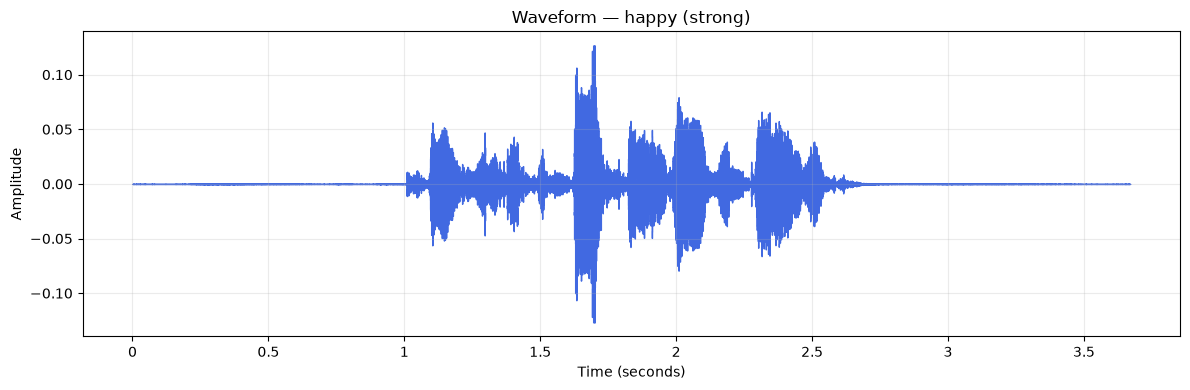

In [7]:
from pathlib import Path
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display

# 读取刚刚生成的标签表
metadata = pd.read_csv("data/metadata/ravdess_metadata.csv")

# 选择一个“强烈高兴”的音频样本
sample = metadata[
    (metadata["emotion"] == "happy") &
    (metadata["intensity"] == "strong")
].iloc[0]

audio_path = Path(sample["file_path"])

# sr=None 表示保留音频原始采样率
waveform, sample_rate = librosa.load(
    audio_path,
    sr=None,
    mono=True
)

duration = librosa.get_duration(
    y=waveform,
    sr=sample_rate
)

print("File:", audio_path)
print("Emotion:", sample["emotion"])
print("Intensity:", sample["intensity"])
print("Actor:", sample["actor_id"])
print("Gender:", sample["gender"])
print("Sample rate:", sample_rate, "Hz")
print("Duration:", round(duration, 2), "seconds")
print("Number of samples:", len(waveform))

# 播放音频
display(Audio(waveform, rate=sample_rate))

# 绘制波形
plt.figure(figsize=(12, 4))
librosa.display.waveshow(
    waveform,
    sr=sample_rate,
    color="royalblue"
)

plt.title(
    f"Waveform — {sample['emotion']} "
    f"({sample['intensity']})"
)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Original duration: 3.67 seconds
Duration after trimming: 1.7 seconds
Log-Mel shape: (128, 54)
Minimum value: -80.0 dB
Maximum value: 0.0 dB


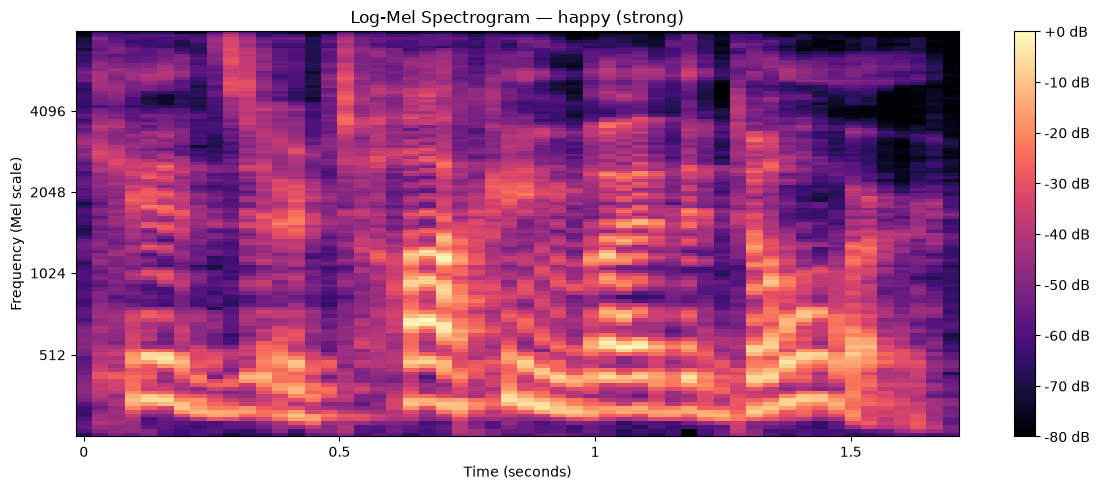

In [8]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# 统一采样率，语音识别通常使用 16000 Hz
target_sample_rate = 16000

audio_16k, _ = librosa.load(
    audio_path,
    sr=target_sample_rate,
    mono=True
)

# 去除音频前后的静音
audio_trimmed, trim_index = librosa.effects.trim(
    audio_16k,
    top_db=30
)

# 计算 Mel 频谱
mel_spectrogram = librosa.feature.melspectrogram(
    y=audio_trimmed,
    sr=target_sample_rate,
    n_fft=1024,
    hop_length=512,
    n_mels=128,
    fmin=20,
    fmax=8000,
    power=2.0
)

# 转换为分贝刻度
log_mel_spectrogram = librosa.power_to_db(
    mel_spectrogram,
    ref=np.max
)

print("Original duration:",
      round(len(audio_16k) / target_sample_rate, 2),
      "seconds")

print("Duration after trimming:",
      round(len(audio_trimmed) / target_sample_rate, 2),
      "seconds")

print("Log-Mel shape:", log_mel_spectrogram.shape)
print("Minimum value:", round(log_mel_spectrogram.min(), 2), "dB")
print("Maximum value:", round(log_mel_spectrogram.max(), 2), "dB")

plt.figure(figsize=(12, 5))

img = librosa.display.specshow(
    log_mel_spectrogram,
    sr=target_sample_rate,
    hop_length=512,
    x_axis="time",
    y_axis="mel",
    fmin=20,
    fmax=8000,
    cmap="magma"
)

plt.colorbar(img, format="%+2.0f dB")
plt.title(
    f"Log-Mel Spectrogram — "
    f"{sample['emotion']} ({sample['intensity']})"
)
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Mel scale)")
plt.tight_layout()
plt.show()

Number of audio samples: 64000
Fixed duration: 4.0 seconds
Fixed Log-Mel shape: (128, 126)


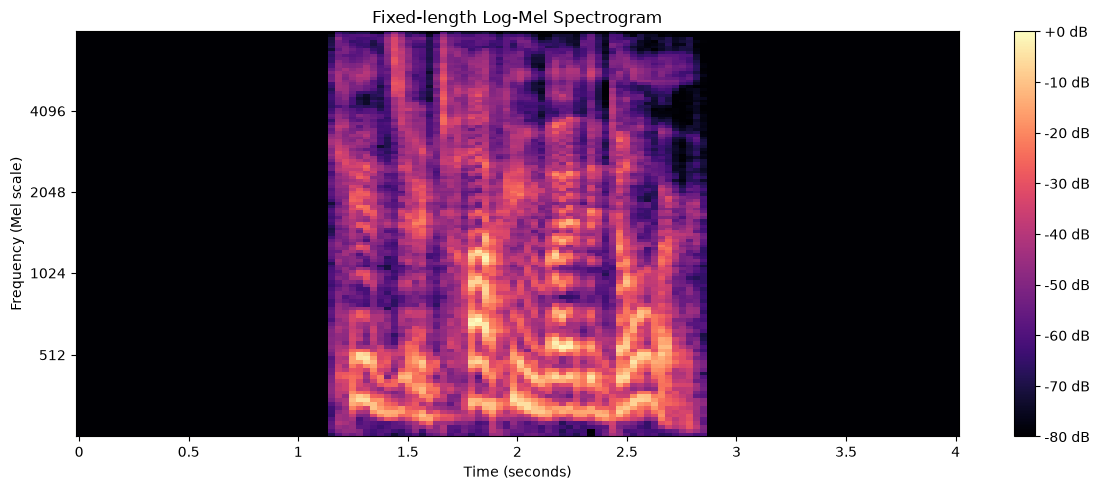

In [9]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

TARGET_SR = 16000
DURATION = 4.0
TARGET_LENGTH = int(TARGET_SR * DURATION)

def load_and_fix_audio(
    file_path,
    target_sr=TARGET_SR,
    duration=DURATION,
    top_db=30
):
    # 1. 读取并重采样
    audio, _ = librosa.load(
        file_path,
        sr=target_sr,
        mono=True
    )

    # 2. 去除首尾静音
    audio, _ = librosa.effects.trim(
        audio,
        top_db=top_db
    )

    target_length = int(target_sr * duration)

    # 3. 不足目标长度：左右补零（补静音）
    if len(audio) < target_length:
        total_padding = target_length - len(audio)
        left_padding = total_padding // 2
        right_padding = total_padding - left_padding

        audio = np.pad(
            audio,
            (left_padding, right_padding),
            mode="constant"
        )

    # 4. 超过目标长度：截取中间部分
    elif len(audio) > target_length:
        start = (len(audio) - target_length) // 2
        audio = audio[start:start + target_length]

    return audio.astype(np.float32)


# 测试刚才的音频
fixed_audio = load_and_fix_audio(audio_path)

fixed_mel = librosa.feature.melspectrogram(
    y=fixed_audio,
    sr=TARGET_SR,
    n_fft=1024,
    hop_length=512,
    n_mels=128,
    fmin=20,
    fmax=8000,
    power=2.0
)

fixed_log_mel = librosa.power_to_db(
    fixed_mel,
    ref=np.max
)

print("Number of audio samples:", len(fixed_audio))
print("Fixed duration:", len(fixed_audio) / TARGET_SR, "seconds")
print("Fixed Log-Mel shape:", fixed_log_mel.shape)

plt.figure(figsize=(12, 5))

img = librosa.display.specshow(
    fixed_log_mel,
    sr=TARGET_SR,
    hop_length=512,
    x_axis="time",
    y_axis="mel",
    fmin=20,
    fmax=8000,
    cmap="magma"
)

plt.colorbar(img, format="%+2.0f dB")
plt.title("Fixed-length Log-Mel Spectrogram")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Mel scale)")
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
from pathlib import Path

metadata = pd.read_csv(
    "data/metadata/ravdess_metadata.csv"
)

train_actors = list(range(1, 17))
validation_actors = list(range(17, 21))
test_actors = list(range(21, 25))

def assign_split(actor_id):
    if actor_id in train_actors:
        return "train"
    elif actor_id in validation_actors:
        return "validation"
    elif actor_id in test_actors:
        return "test"
    else:
        raise ValueError(f"Unknown actor: {actor_id}")

metadata["split"] = metadata["actor_id"].apply(assign_split)

# 检查三个集合的演员没有重叠
train_set = set(metadata.loc[
    metadata["split"] == "train", "actor_id"
])

validation_set = set(metadata.loc[
    metadata["split"] == "validation", "actor_id"
])

test_set = set(metadata.loc[
    metadata["split"] == "test", "actor_id"
])

assert train_set.isdisjoint(validation_set)
assert train_set.isdisjoint(test_set)
assert validation_set.isdisjoint(test_set)

# 保存带数据集划分的标签表
output_path = Path(
    "data/metadata/ravdess_metadata_split.csv"
)

metadata.to_csv(output_path, index=False)

print("Saved to:", output_path.resolve())

print("\nNumber of audio files:")
print(metadata["split"].value_counts())

print("\nNumber of actors:")
print(
    metadata.groupby("split")["actor_id"].nunique()
)

print("\nActors in each split:")
for split_name in ["train", "validation", "test"]:
    actors = sorted(
        metadata.loc[
            metadata["split"] == split_name,
            "actor_id"
        ].unique()
    )
    print(f"{split_name}: {actors}")

print("\nEmotion distribution:")
display(
    pd.crosstab(
        metadata["emotion"],
        metadata["split"]
    )
)

print("\nGender distribution:")
display(
    pd.crosstab(
        metadata["gender"],
        metadata["split"]
    )
)

Saved to: D:\Robotique\Appentisage\CNN_Documents\data\metadata\ravdess_metadata_split.csv

Number of audio files:
split
train         960
validation    240
test          240
Name: count, dtype: int64

Number of actors:
split
test           4
train         16
validation     4
Name: actor_id, dtype: int64

Actors in each split:
train: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]
validation: [np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
test: [np.int64(21), np.int64(22), np.int64(23), np.int64(24)]

Emotion distribution:


split,test,train,validation
emotion,,,
angry,32,128,32
calm,32,128,32
disgust,32,128,32
fearful,32,128,32
happy,32,128,32
neutral,16,64,16
sad,32,128,32
surprised,32,128,32



Gender distribution:


split,test,train,validation
gender,,,
female,120,480,120
male,120,480,120


In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm

metadata = pd.read_csv(
    "data/metadata/ravdess_metadata_split.csv"
)

feature_dir = Path("data/processed/log_mel")
feature_dir.mkdir(parents=True, exist_ok=True)

# 标签编号固定为0～7
emotion_names = [
    "neutral",
    "calm",
    "happy",
    "sad",
    "angry",
    "fearful",
    "disgust",
    "surprised",
]

emotion_to_id = {
    emotion: index
    for index, emotion in enumerate(emotion_names)
}

metadata["label_id"] = metadata["emotion"].map(emotion_to_id)


def audio_to_log_mel(file_path):
    # 使用上一步定义的函数：
    # 读取、重采样、去静音、补齐到4秒
    audio = load_and_fix_audio(file_path)

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=TARGET_SR,
        n_fft=1024,
        hop_length=512,
        n_mels=128,
        fmin=20,
        fmax=8000,
        power=2.0
    )

    log_mel = librosa.power_to_db(
        mel,
        ref=np.max,
        top_db=80
    )

    # 将[-80, 0]归一化为[0, 1]
    normalized_log_mel = (log_mel + 80.0) / 80.0
    normalized_log_mel = np.clip(
        normalized_log_mel,
        0.0,
        1.0
    )

    return normalized_log_mel.astype(np.float32)


feature_paths = []

for row in tqdm(
    metadata.itertuples(index=False),
    total=len(metadata),
    desc="Generating Log-Mel features"
):
    audio_path = Path(row.file_path)
    feature_path = feature_dir / f"{audio_path.stem}.npy"

    # 如果中途停止，重新运行时跳过已经生成的文件
    if not feature_path.exists():
        feature = audio_to_log_mel(audio_path)
        np.save(feature_path, feature)

    feature_paths.append(feature_path.as_posix())

metadata["feature_path"] = feature_paths

prepared_metadata_path = Path(
    "data/metadata/ravdess_prepared.csv"
)

metadata.to_csv(
    prepared_metadata_path,
    index=False
)

# 完整性检查
existing_features = list(feature_dir.glob("*.npy"))
example_feature = np.load(metadata.iloc[0]["feature_path"])

print("\nNumber of feature files:", len(existing_features))
print("Example feature shape:", example_feature.shape)
print("Data type:", example_feature.dtype)
print("Minimum value:", example_feature.min())
print("Maximum value:", example_feature.max())
print("Prepared metadata:", prepared_metadata_path.resolve())

assert len(existing_features) == 1440
assert example_feature.shape == (128, 126)
assert metadata["label_id"].notna().all()

print("\nAll features generated successfully.")

Generating Log-Mel features: 100%|██████████| 1440/1440 [00:22<00:00, 62.74it/s]


Number of feature files: 1440
Example feature shape: (128, 126)
Data type: float32
Minimum value: 0.0
Maximum value: 1.0
Prepared metadata: D:\Robotique\Appentisage\CNN_Documents\data\metadata\ravdess_prepared.csv

All features generated successfully.
